# Fake News Detection Using Machine Learning Algorithms

In [8]:
%matplotlib inline

In [9]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: C:\Users\kalina\anaconda3\python.exe -m pip install --upgrade pip


In [10]:
pip install hyperopt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: C:\Users\kalina\anaconda3\python.exe -m pip install --upgrade pip


In [11]:
pip install mlflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: C:\Users\kalina\anaconda3\python.exe -m pip install --upgrade pip


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud, STOPWORDS

from collections import Counter
import re

import nltk
import string

from nltk.tokenize import word_tokenize
from collections import Counter
from collections import defaultdict

nltk.download('punkt')
nltk.download('averaged_perceptron_tagger') 

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_recall_fscore_support,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.metrics import roc_curve, auc

from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MaxAbsScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from hyperopt import hp, tpe, Trials, fmin
import mlflow
import mlflow.sklearn
import pickle



[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\kalina\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\kalina\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


### Introduction into fake news detection

The open nature of the web and social media in addition to the recent advance in computer science has simplified the process of creating and spreading fake news. The phenomenon has gained a lot of attention after the US election in 2016 and the Brexit referendum in 2016. Then it further escalated with the Covid-19 pandemic at the end of 2019, and most recently, in the context of the war propaganda employed by Russia in its aggression against Ukraine.

Fake news can be simply defined as those news stories that are false: the story itself is fabricated, with no verifiable facts, sources or quotes. Sometimes these stories may be propaganda that is intentionally designed to mislead the reader, or may be designed as “clickbait” written for economic incentives. Nevertheless, it is a complex and nuanced problem, that has become politicized, and is widely used to discredit any opposing viewpoint. Some people use it to cast doubt on their opponents, controversial issues or the credibility of some media organizations. 

It is tough for humans to detect fake news. It can be argued that the only way for a person to manually identify fake news is to have a vast knowledge of the covered topic, hence, the need for an automatic process. The importance of creating such a process cannot be overestimated. Misinformation may cause political and societal decisions that run counter to a society’s best interest. While truth is hard to detect computational, early warning systems can assist both fact-checkers and news readers in their decisions. Additionally, understanding what features distinguishes types of news can help us understand how users are persuaded.

Fake news has certain standard features or characteristics, including low facticity, journalistic styles (such as structural elements like headline, text, and body) and intention to deceive for personal benefits, such as financial, political, or to provoke someone are examples of these. Other characteristics include grammatical and spelling errors.

In fake news research, various methods are used to detect them. This includes applying Natural Language Processing (NLP) techniques like sentiment analysis and linguistic pattern recognition to analyze news and social media content. Machine learning algorithms, both supervised and unsupervised, help classify news as real or fake based on factors like source credibility and textual characteristics. Network-based methods track the spread of false information on social networks. Deep learning, using CNNs and RNNs, extracts relevant features from text and media to identify fake news. (References 1, 2, 3, 4 and 6)


### Goal of paper

Explore, test and compare a number of machine learning algorithms on the [ISOT Fake News Dataset](https://www.kaggle.com/datasets/aadiola/isot-fake-news-dataset) to achieve the highest scores in a set of performance metrics. Prior to that, perfom EDA and feature extraction on the dataset. Create a pipeline and save the results. To achieve this goal, a number of best practices based on previous research will be used.

### Previous research:

The main and most relevant points of three papers are presented below:

**Paper 1**: [This Just In: Fake News Packs a Lot in Title, Uses Simpler, Repetitive Content in Text Body, More Similar to Satire than Real News](https://arxiv.org/pdf/1703.09398) by Benjamin D. Horne, Sibel Adali

The researchers asked the question: Are there any systematic stylistic and other content differences between fake and real news?

They used three types of news (real, satire and fake) in two different independent data sets of political news. The researchers employed ANOVA and Wilcoxon tests to find significant shifts in feature distributions and then used linear kernel SVMs on the top four most statistically significant features to determine the predictive power of features. The top four features from their statistical analysis are number of nouns, lexical redundancy (TTR), word count, and number of quotes. 

Here is a list of all features (complexity, psychology and stylistic) the researchers examined:

![Features](Features.png)

Here are the stastically significant features, calculate using one-way ANOVA or the Wilcoxon rank sum. The top 4 features are number of nouns, lexical redundancy (TTR), word count, and number of quotes:

![Features_result1](Features_result1.png)
![Features_result2](Features_result2.png)

The results show that real and fake news are clearly distinguishable, especially in the title of the articles. Fake news articles use significantly more proper names and verbs, while significantly fewer stop words and nouns are used. 

![Horne & Adali Research](Horne%20%26%20Adali%20Research.png)

The authors also conclude that the style and complexity of the content in fake news articles is more similar to the content of satirical news, leading to the conclusion that the persuasive power of fake news articles is not achieved by the strength of the arguments, but by heuristics. They also showed that their features can be used to significantly improve the prediction of fake and satire news, achieving between 71% and 91% accuracy in separating from real news stories. Furthermore, the authors found that the general assumption that fake news is written to look like real news to fool the recipient is not true. This leads them to the conclusion that fake news is intended for an audience that is unlikely to read beyond the titles and that aims to make mental associations between claims and entities. (References 4 and 5) 

**Paper 2**: [Detection of Online Fake News Using N-Gram Analysis and Machine Learning Techniques](https://sci-hub.se/10.1007/978-3-319-69155-8_9) by Hadeer Ahmed, Issa Traore and Sherif Saad

The paper suggest a fake news detection model that use n-gram analysis and machine learning techniques. 

The preprocessing of data included stop-word removal, tokenization, lower casing, sentence segmentation, punctuation removal and stemming using the Porter stemmer. The researchers investigated and compares two different features extraction techniques, Term Frequency (TF) and Term Frequency-Inverted Document Frequency (TF-IDF). Four different sizes of the n-gram from $n = 1$ to $n = 4$ and four different number of features $p$ (i.e., top features selected), ranging from 1,000 to 50,000, were also tested. The researchers used 5-fold cross validation, so in each validation around 80% of the dataset was used for training and 20% for testing.

The following machine learning algorithms were tested: Stochastic Gradient Descent (SGD), Support Vector Machines (SVM), Linear Support Vector Machines (LSVM), K-Nearest Neighbour (KNN) and Decision Trees (DT).

Among the tested models, the linear-based classifiers (Linear SVM, SDG, and Logistic regression) achieved better results than nonlinear ones. However, nonlinear classifiers achieved good results too, the Decision Tree achieved 89% accuracy. The highest accuracy was achieved using Linear SVM at 92%. This classifier performs well no matter the number of feature values used. Also with the increase of n-gram (Tri-gram, Four-gram), the accuracy of the algorithm decreases. Furthermore, TF-IDF outperformed TF. The lowest accuracy of 47.2% was achieved using KNN and SVM with four-gram words and 50,000 and 10,000 feature values.


**Paper 3**: [Fake News Detection Using Machine Learning Ensemble Methods](https://onlinelibrary.wiley.com/doi/10.1155/2020/8885861) by Iftikhar Ahmad, Muhammad Yousaf, Suhail Yousaf, Muhammad Ovais Ahmad

The main goal of the research is to identify patterns in  the text that differentiate fake news from true news using "the machine learning ensemble approach". According to the authors, the ensemble techniques along with Linguistic Inquiry and Word Count (LIWC) feature set are the novelty of their proposed approach.

The study tested 4 datasets and used LIWC2015 as a linguistic features extracting tool. Each dataset was divided into training and testing set with a 70/30 split and each model was trained multiple times with a set of different parameters using a grid search to optimize the model for the best outcome. 

The researchers tested Logistic Regression, Support Vector Machine (SVM), Multilayer Perceptron, K-Nearest Neighbors (KNN), as well as several ensemble learners - Random Forest (RF), Bagging Ensemble Classifiers (an ensemble of 100 decision trees), two boosting ensemble algorithms, XGBoost and AdaBoost, and two voting classifiers composed of three learning models: 
1. Voting classifier which is an ensemble of logistic regression, random forest, and KNN
2. Voting classifier which is an ensemble of logistic regression, linear SVM, and classification and regression trees (CART)

The best performing algorithm proved to be the bagging classifier (accuracy 94%). Individual learners’ accuracy was 77.6% whereas the accuracy of ensemble learners was 92.25%. Overall, the ensemble learner XGBoost performed better in comparison to other learning models on all performance metrics. The main factor leading to the superior performance of XGBoost is the working principle which efficiently identifies errors and minimizes them in each iteration.

Here are the results for accuracy for all algorithms over each dataset:

![Table2](table2.png)

Here is a summariry of the avarage accuracy

![Figure2](Figure2.png)



### The Dataset
The dataset consists of two CSV files. The first (True.csv) contains more than 12,600 articles from reuters.com. The second file (Fake.csv) contains more than 12,600 articles from different fake news outlet resources. 

Each article contains the following information: article title, text, type and the date the article was published. Most of the news are from 2016 to 2017. According to the researchers who compiled the datasets, they were cleaned and processed, however, the punctuations and mistakes that existed in the fake news were kept in the text.

The news in the dataset concern the United States and some conext of the events at that time is relevant for this research. In 2016, the US presidential election was the central story, with Donald Trump’s surprise victory over Hillary Clinton, which sparked widespread political debate and protests. The year also saw heightened attention on issues like police brutality, racial tensions, and mass shootings, with the tragic events of the Pulse nightclub shooting in in Orlando and the police shooting in Dallas. Meanwhile, global issues such as the Brexit referendum in the UK also made waves in US media. In 2017, the political landscape continued to be shaped by President Trump’s administration, with controversies surrounding his executive orders, the investigation into Russian interference in the election, and the introduction of the travel ban for refugees coming from certain countries. Additionally, the #MeToo movement gained momentum, spotlighting sexual harassment across various industries. (References 7 and 8) 


### Data analysis and pre-processing:

To start, let's load the datasets and check the first 5 rows and the shape of each of them.

In [13]:
fake_news = pd.read_csv("Fake.csv")
real_news = pd.read_csv("True.csv")

**As the datasets are too large they can be found [here](https://github.com/KalinaMarkova/Machine-Learning-Course-Project)**

In [14]:
fake_news.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [15]:
fake_news.shape

(23481, 4)

In [16]:
real_news.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [17]:
real_news.shape

(21417, 4)

Let's check for missing values, drop the duplicates and check again the shape.

In [18]:
fake_news.isna().sum()

title      0
text       0
subject    0
date       0
dtype: int64

In [19]:
real_news.isna().sum()

title      0
text       0
subject    0
date       0
dtype: int64

In [20]:
fake_news_no_dupes = fake_news.drop_duplicates(subset = ['title', 'text'], keep = 'first')
real_news_no_dupes = real_news.drop_duplicates(subset = ['title', 'text'], keep = 'first')

In [21]:
fake_news_no_dupes.shape

(17908, 4)

In [22]:
real_news_no_dupes.shape

(21197, 4)

It seems that the number duplicates (articles that have identical title and text) in the fake news dataset is much larger. It may be due to some unknown specifics in the data gathering or the fact that fake news are spread by the so-called mushroom websites that publish the same articles (Reference 9). 
Let's calculate and visualise the number of duplicates in each set: 

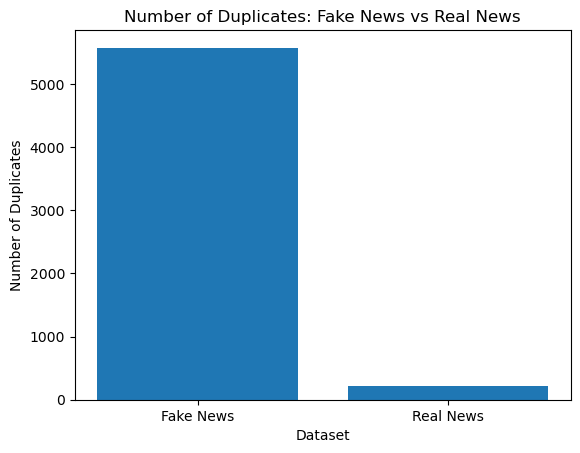

In [23]:
fake_duplicates = fake_news.duplicated(subset = ['title', 'text']).sum()
real_duplicates = real_news.duplicated(subset = ['title', 'text']).sum()

plt.bar(['Fake News', 'Real News'], [fake_duplicates, real_duplicates]       )
plt.xlabel('Dataset')
plt.ylabel('Number of Duplicates')
plt.title('Number of Duplicates: Fake News vs Real News')
plt.show()


In [24]:
fake_duplicates

5573

In [25]:
real_duplicates

220

In addition, we can see that in the Real News dataset, each text starts with the city of report followed by "(Reuters)". Let's trim these, as they can provide clues to our models in determining which news are real.

In [26]:
real_news_no_dupes['text'] = real_news_no_dupes['text'].apply(lambda x: ' '.join(x.split()[2:]).lstrip('-').strip())


C:\Users\kalina\AppData\Local\Temp\ipykernel_8740\3407222886.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  real_news_no_dupes['text'] = real_news_no_dupes['text'].apply(lambda x: ' '.join(x.split()[2:]).lstrip('-').strip())


In [27]:
real_news_no_dupes

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",The head of a conservative Republican faction ...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,Transgender people will be allowed for the fir...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,The special counsel investigation of links bet...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,Trump campaign adviser George Papadopoulos tol...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,President Donald Trump called on the U.S. Post...,politicsNews,"December 29, 2017"
...,...,...,...,...
21412,'Fully committed' NATO backs new U.S. approach...,NATO allies on Tuesday welcomed President Dona...,worldnews,"August 22, 2017"
21413,LexisNexis withdrew two products from Chinese ...,"LexisNexis, a provider of legal, regulatory an...",worldnews,"August 22, 2017"
21414,Minsk cultural hub becomes haven from authorities,In the shadow of disused Soviet-era factories ...,worldnews,"August 22, 2017"
21415,Vatican upbeat on possibility of Pope Francis ...,Vatican Secretary of State Cardinal Pietro Par...,worldnews,"August 22, 2017"


Let's explore the **lenght (in characters)** of the titles and texts in both dataset. 

In [28]:
# Save fake news dataset
fake_news_no_dupes.to_csv("fake_news_no_dupes.csv", index=False)

# Save real news dataset
real_news_no_dupes.to_csv("real_news_no_dupes.csv", index=False)

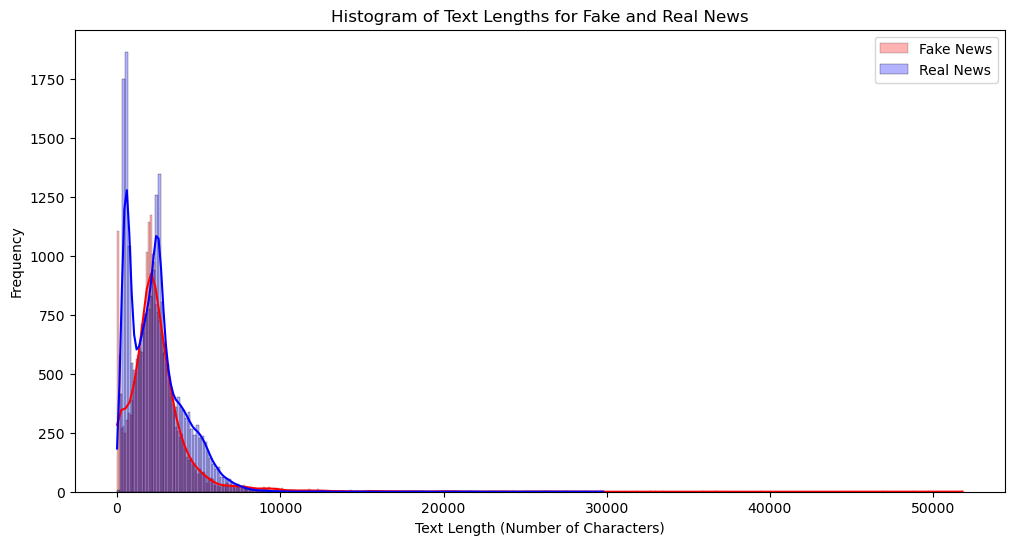

In [22]:
# Calculate text lengths
fake_news['text_length'] = fake_news['text'].str.len()
real_news['text_length'] = real_news['text'].str.len()

# Combined Plot for Fake News and Real News
plt.figure(figsize=(12, 6))

# Fake News Histogram
sns.histplot(fake_news['text_length'], bins = 'fd', color = 'red', label = 'Fake News', kde = True, alpha = 0.3)

# Real News Histogram
sns.histplot(real_news['text_length'], bins = 'fd', color = 'blue', label = 'Real News', kde = True, alpha = 0.3)

plt.title('Histogram of Text Lengths for Fake and Real News')
plt.xlabel('Text Length (Number of Characters)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [23]:
# Calculate the mean text length for fake news
mean_fake_text_length = fake_news['text_length'].mean()

# Calculate the mean text length for real news
mean_real_text_length = real_news['text_length'].mean()

# Print the results
print(f"Mean Text Length for Fake News: {mean_fake_text_length}")
print(f"Mean Text Length for Real News: {mean_real_text_length}")

Mean Text Length for Fake News: 2547.396235254035
Mean Text Length for Real News: 2383.278517065882


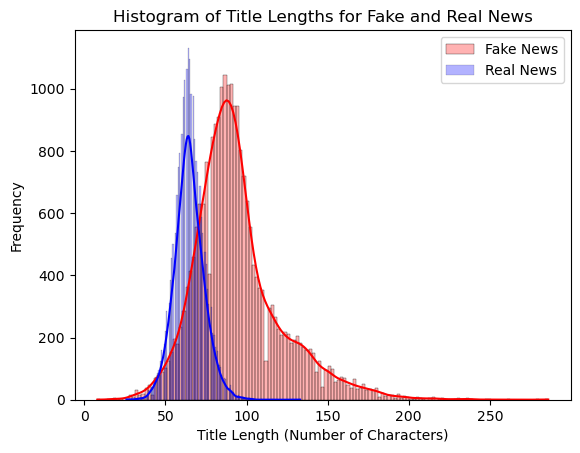

In [24]:
# Calculate title lengths
fake_news['title_length'] = fake_news['title'].str.len()
real_news['title_length'] = real_news['title'].str.len()

# Fake News Histogram
sns.histplot(fake_news['title_length'], bins = 'fd', color = 'red', label = 'Fake News', kde = True, alpha = 0.3)

# Real News Histogram
sns.histplot(real_news['title_length'], bins = 'fd', color = 'blue', label = 'Real News', kde = True, alpha = 0.3)

plt.title('Histogram of Title Lengths for Fake and Real News')
plt.xlabel('Title Length (Number of Characters)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [25]:
# Calculate the mean, smallest, and largest title length for fake news
mean_fake_title_length = fake_news['title_length'].mean()
min_fake_title_length = fake_news['title_length'].min()
max_fake_title_length = fake_news['title_length'].max()

# Calculate the mean, smallest, and largest title length for real news
mean_real_title_length = real_news['title_length'].mean()
min_real_title_length = real_news['title_length'].min()
max_real_title_length = real_news['title_length'].max()

# Print the results
print(f"Mean Title Length for Fake News: {mean_fake_title_length}")
print(f"Smallest Title Length for Fake News: {min_fake_title_length}")
print(f"Largest Title Length for Fake News: {max_fake_title_length}")

print(f"Mean Title Length for Real News: {mean_real_title_length}")
print(f"Smallest Title Length for Real News: {min_real_title_length}")
print(f"Largest Title Length for Real News: {max_real_title_length}")


Mean Title Length for Fake News: 94.19803245176952
Smallest Title Length for Fake News: 8
Largest Title Length for Fake News: 286
Mean Title Length for Real News: 64.667880655554
Smallest Title Length for Real News: 26
Largest Title Length for Real News: 133


**The titles of fake news are clearly longer in terms of characters, while the difference in text lenght is not so big.**

Let's make **wordclouds** with each of datasets to see which words are the most frequent. For this, we need news-specific stopwords, and thankfully super GitHub user [vikasing](https://github.com/vikasing) has kindly shared [them](https://github.com/vikasing/news-stopwords/tree/master). 


In [26]:
sw1k_stopwords = set(pd.read_csv("sw1k.csv", usecols = ["term"])["term"])

news_stopwords = STOPWORDS.union(sw1k_stopwords)

def generate_wordcloud(text_data, stopwords, title, random_state = 42):
    text = " ".join(text_data.dropna().astype(str))
    
    wordcloud = WordCloud(
        stopwords = stopwords,
        width = 1600,
        height = 800,
        max_words = 100,
        background_color = 'white',
        colormap = 'rainbow',
        random_state = random_state
    ).generate(text)
    
    
    plt.figure(figsize = ( 12, 6))
    plt.imshow(wordcloud, interpolation = 'bilinear')
    plt.axis('off')
    plt.title(title, fontsize = 16, loc = 'center')
    plt.show()

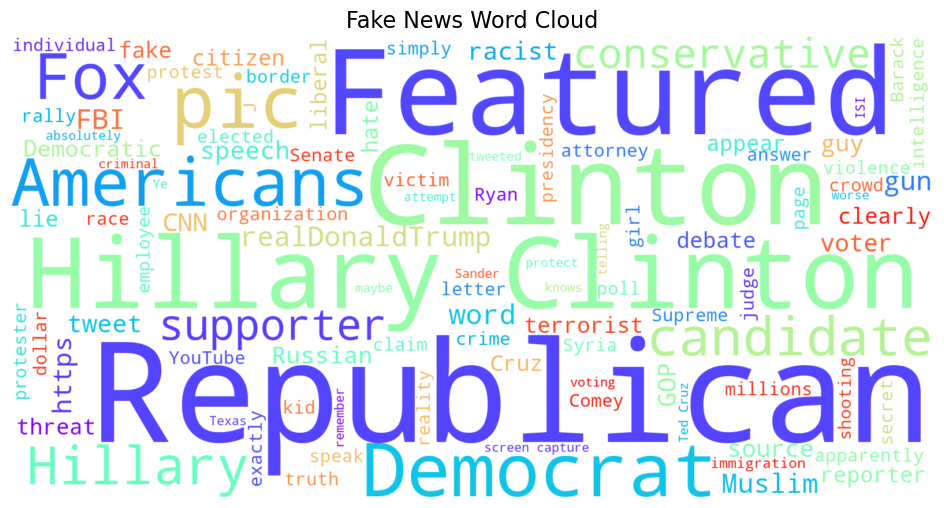

In [27]:
# Generate word cloud for fake news
generate_wordcloud(fake_news_no_dupes["text"], news_stopwords, title = "Fake News Word Cloud")

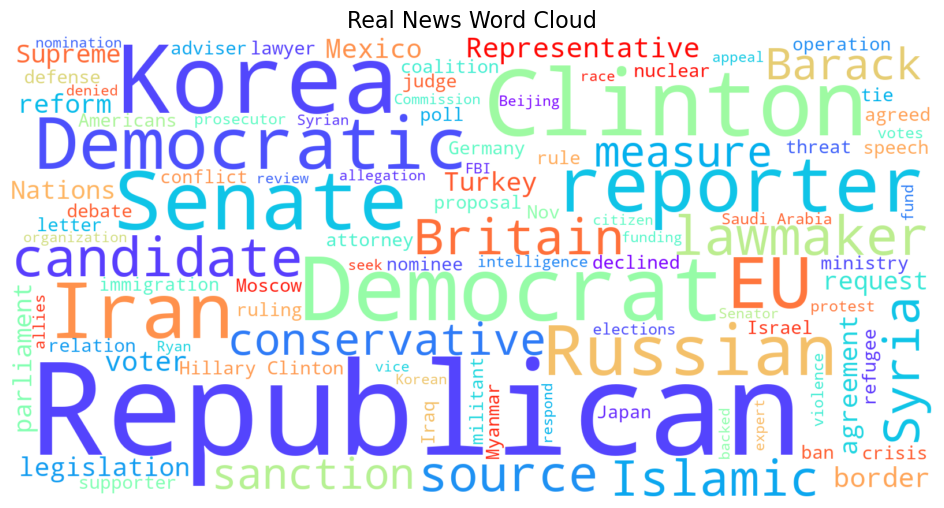

In [28]:
# Generate word cloud for real news
generate_wordcloud(real_news_no_dupes["text"], news_stopwords, title = "Real News Word Cloud")

Let's get the top ten most frequent words of each dataset:

In [29]:
def get_top_words(text_data, top_n = 10):
    all_text = " ".join(text_data.dropna().astype(str))
    
    all_text = re.sub(r'[^a-zA-Z\s]', '', all_text).lower()
    
    words = [word for word in all_text.split() if word not in news_stopwords]
    
    word_counts = Counter(words)
    
    return word_counts.most_common(top_n)

In [30]:
fake_top_words = get_top_words(fake_news_no_dupes["text"], top_n = 10)
print("Top 10 words and their frequencies in Fake News:")
for word, freq in fake_top_words:
    print(f"{word}: {freq}")

Top 10 words and their frequencies in Fake News:
clinton: 12701
hillary: 9556
republican: 7712
republicans: 6358
americans: 4575
fox: 4081
realdonaldtrump: 3904
gop: 3704
fbi: 3694
democratic: 3448


In [31]:
real_top_words = get_top_words(real_news_no_dupes["text"], top_n = 10)
print("Top 10 words and their frequencies in Real News:")
for word, freq in real_top_words:
    print(f"{word}: {freq}")

Top 10 words and their frequencies in Real News:
republican: 15197
trumps: 11637
senate: 8914
democratic: 8160
clinton: 7809
republicans: 6766
korea: 6650
russian: 5468
democrats: 5200
iran: 5103


Inspecting the most frequently used words, we see that some words (**republican, democratic, trump and clinton**) are top words for both datasets. The unique words in Fake News are **fox, gop, fbi and americans**, while in Real News are **senate, korea, russia and iran**, showing the difference in focus on current topics. 

Let's add a target column, combine the datasets and shuffle all rows.

In [32]:
real_news_no_dupes.loc[:, 'target'] = 0
fake_news_no_dupes.loc[:, 'target'] = 1

df = pd.concat([real_news_no_dupes, fake_news_no_dupes], ignore_index = True)

df = df.sample(frac = 1, random_state = 42).reset_index(drop = True)

C:\Users\kalina\AppData\Local\Temp\ipykernel_8772\615712899.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  real_news_no_dupes.loc[:, 'target'] = 0
C:\Users\kalina\AppData\Local\Temp\ipykernel_8772\615712899.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fake_news_no_dupes.loc[:, 'target'] = 1


In [33]:
df.head()

,title,text,subject,date,target
0,This Church Treasurer Is Going To Jail For A ...,A church treasurer from Ohio is going to jail ...,News,"February 26, 2016",1
1,SENATOR FEINSTEIN Shocks CNN Anchor With “Prec...,"What s all the fuss about if there s no there,...",politics,"May 5, 2017",1
2,Hillary Clinton Supporters Now Calling for a R...,The person who received the most votes free f...,US_News,"November 23, 2016",1
3,U.S. appeals court upholds conviction over sha...,A divided federal appeals court on Tuesday gav...,politicsNews,"July 5, 2016",0
4,Kenya's Supreme Court upholds Kenyatta's presi...,Kenya s Supreme Court on Monday upheld the re-...,worldnews,"November 20, 2017",0


In [34]:
df.shape

(39105, 5)

Let's check the proportion of fake and real news.

In [35]:
df.target.value_counts(normalize = True)

target
0    0.542053
1    0.457947
Name: proportion, dtype: float64

We can see that the combined dataset is relatively balanced in terms of the target value, fake news are 54% while real news are 46%.

Let's see the unique subjects in the combined dataset.

In [36]:
df['subject'].value_counts()

subject
politicsNews       11217
worldnews           9980
News                9050
politics            6838
US_News              783
left-news            705
Government News      532
Name: count, dtype: int64

We need to standardtize the names of the subject. After that we will calculate the percentages of each subject.

In [37]:
subject_mapping = {
    'politicsNews': 'politics news',
    'worldnews': 'world news',
    'News': 'general news',
    'politics': 'politics news',
    'US_News': 'US news',
    'left-news': 'left news',
    'Government News': 'government news'
}

df['subject'] = df['subject'].replace(subject_mapping)

In [38]:
df['subject'].value_counts()

subject
politics news      18055
world news          9980
general news        9050
US news              783
left news            705
government news      532
Name: count, dtype: int64

In [39]:
subject_counts = df['subject'].value_counts()
subject_percentages = (subject_counts / subject_counts.sum()) * 100

subject_summary = subject_counts.astype(str) + " (" + subject_percentages.round(2).astype(str) + "%)"

print(subject_summary)

subject
politics news      18055 (46.17%)
world news          9980 (25.52%)
general news        9050 (23.14%)
US news                783 (2.0%)
left news              705 (1.8%)
government news       532 (1.36%)
Name: count, dtype: object


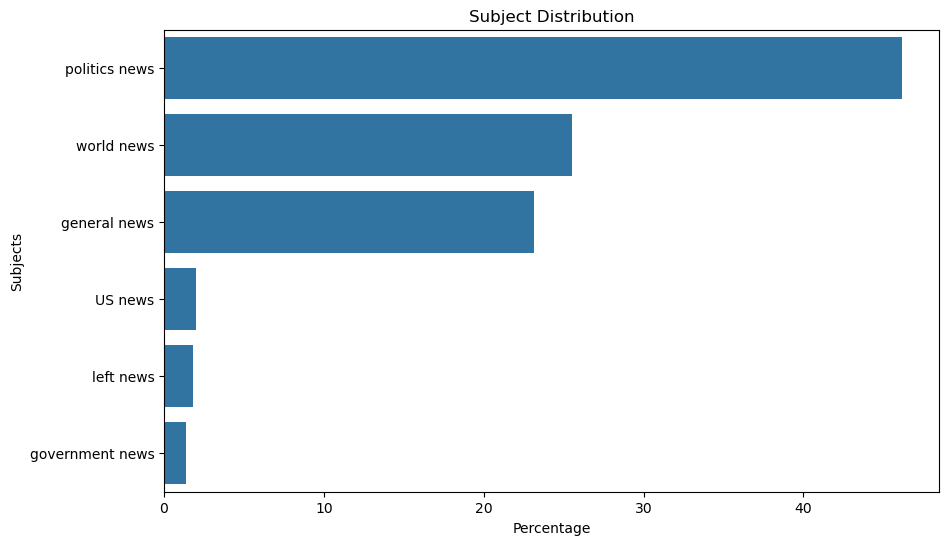

In [40]:
plt.figure(figsize = (10, 6))
sns.barplot(x = subject_percentages.values, y = subject_percentages.index, orient = 'h')

plt.title('Subject Distribution')
plt.xlabel('Percentage')
plt.ylabel('Subjects')
plt.show()


The largest bulk of data is in political news, let's see the distibution within fake and real news.

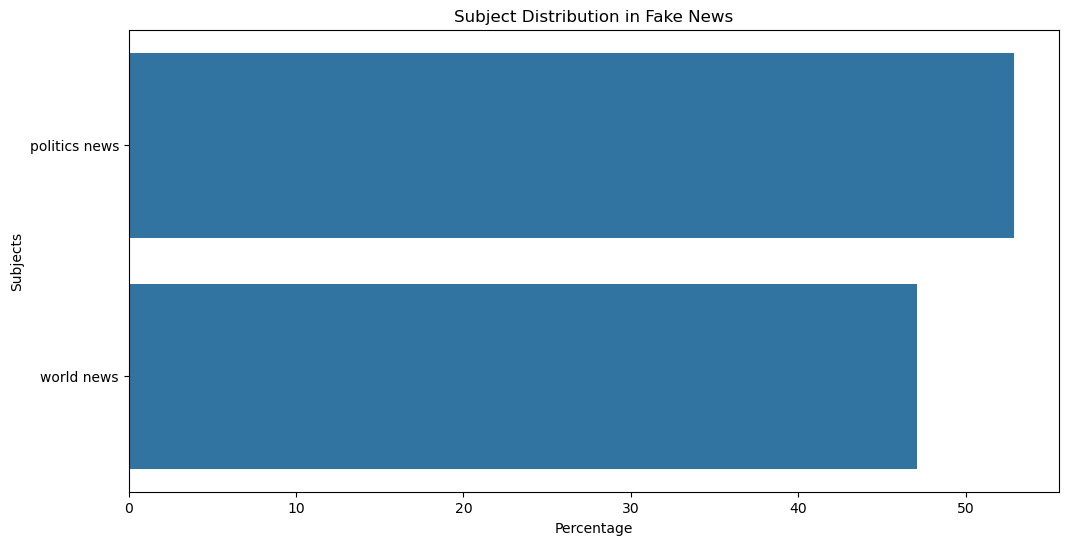

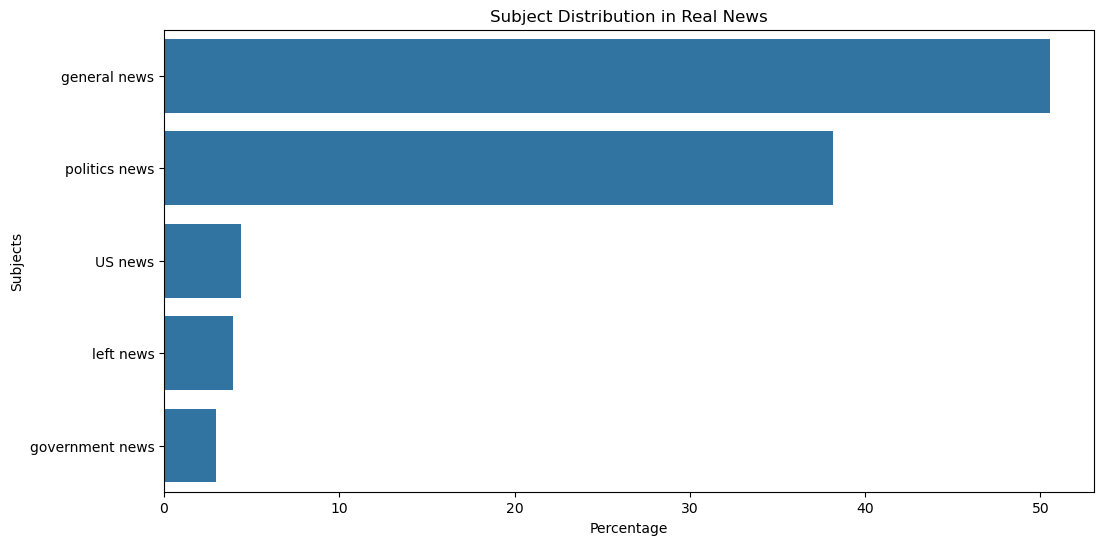

In [41]:

# Calculate subject percentages for fake news
fake_subject_counts = df[df['target'] == 0]['subject'].value_counts()
fake_subject_percentages = (fake_subject_counts / fake_subject_counts.sum()) * 100

# Calculate subject percentages for real news
real_subject_counts = df[df['target'] == 1]['subject'].value_counts()
real_subject_percentages = (real_subject_counts / real_subject_counts.sum()) * 100

# Plot for Fake News Subject Distribution
plt.figure(figsize = (12, 6))
sns.barplot(x = fake_subject_percentages.values, y=fake_subject_percentages.index, orient = 'h')
plt.title('Subject Distribution in Fake News')
plt.xlabel('Percentage')
plt.ylabel('Subjects')
plt.show()

# Plot for Real News Subject Distribution
plt.figure(figsize = (12, 6))
sns.barplot(x = real_subject_percentages.values, y = real_subject_percentages.index, orient = 'h')
plt.title('Subject Distribution in Real News')
plt.xlabel('Percentage')
plt.ylabel('Subjects')
plt.show()


In [42]:
# Calculate counts and percentages for fake news
fake_subject_summary = fake_subject_counts.astype(str) + " (" + fake_subject_percentages.round(2).astype(str) + "%)"

# Calculate counts and percentages for real news
real_subject_summary = real_subject_counts.astype(str) + " (" + real_subject_percentages.round(2).astype(str) + "%)"

# Print summaries
print("Fake News Subject Summary:")
print(fake_subject_summary)
print("\nReal News Subject Summary:")
print(real_subject_summary)

Fake News Subject Summary:
subject
politics news    11217 (52.92%)
world news        9980 (47.08%)
Name: count, dtype: object

Real News Subject Summary:
subject
general news       9050 (50.54%)
politics news      6838 (38.18%)
US news              783 (4.37%)
left news            705 (3.94%)
government news      532 (2.97%)
Name: count, dtype: object


In fake news, politics news takes the biggest bulk (52.92%), while in real news, general news (50.54%) are the most, followed by politics news (38.18%). It seems that the politics news are more prelevant in fake news, which seems consistent with the fact that fake news are used to influence public opinion in terms of politics. However, it seems that the criteria to classify news in both datasets is different, as in real news, there are more categories. 

Now, let's check the distibution of articles per the year they were published.

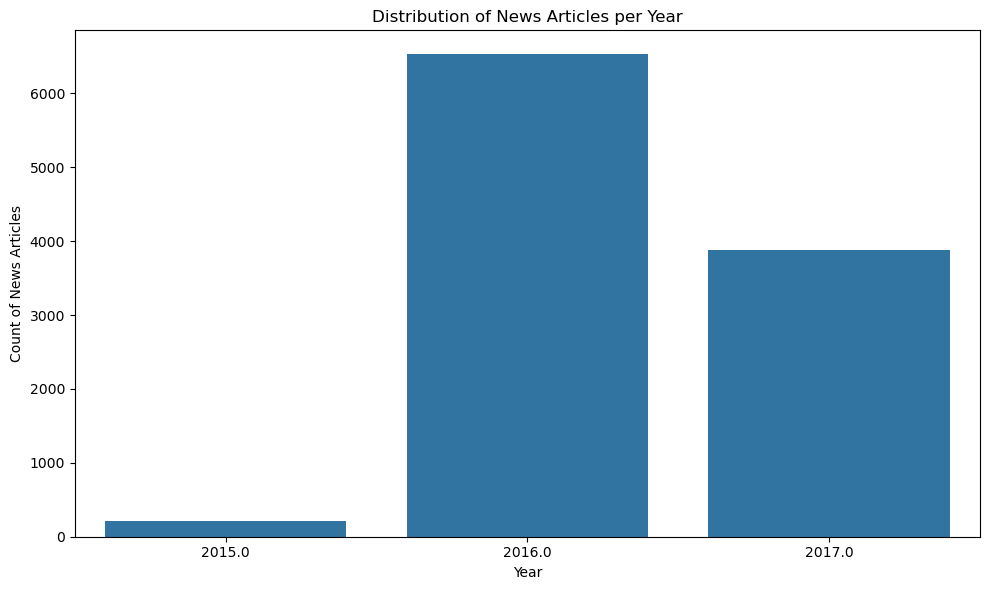

In [43]:
df['date'] = pd.to_datetime(df['date'], format="%B %d, %Y", errors='coerce')


# Extract the year from the 'date' column
df['year'] = df['date'].dt.year

# Count the number of articles per year
year_counts = df['year'].value_counts().sort_index()

# Create the plot
plt.figure(figsize=(10, 6))
sns.barplot(x=year_counts.index, y=year_counts.values)

# Set plot labels and title
plt.title('Distribution of News Articles per Year')
plt.xlabel('Year')
plt.ylabel('Count of News Articles')
plt.tight_layout()

# Display the plot
plt.show()

Most of the news are from 2016, there a small percentange of news is from 2015.

### Feature Extraction

In their datasets, Benjamin D. Horne and Sibel Adali found four top features: number of nouns, lexical redundancy (TTR),
word count, and number of quotes Let's see what we can find in our dataset..

First, let's explore the question whether there is a link between the target and the number of words in both title and text columns:

In [44]:
df_words = pd.DataFrame()
def count_words(column):
    tokenizer = nltk.RegexpTokenizer(r"\w+")
    new_words = tokenizer.tokenize(column)
    return len(new_words)

df_words["n_words_in_title"] = df["title"].apply(count_words)
df_words["n_words_in_text"] = df["text"].apply(count_words)
df_words['target'] = df['target']

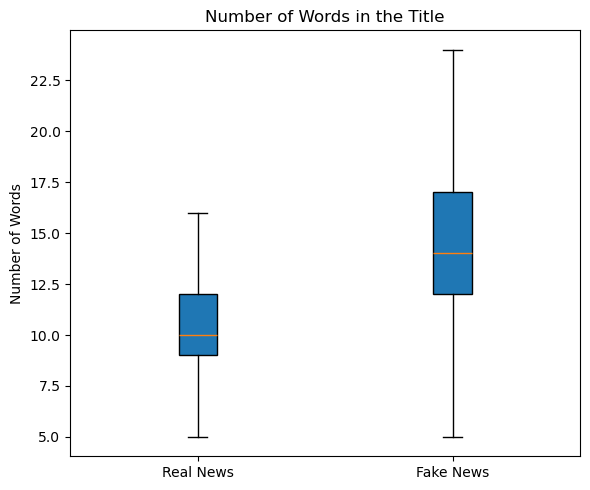

In [45]:
real_title_words = df_words[df_words['target'] == 0]['n_words_in_title']
fake_title_words = df_words[df_words['target'] == 1]['n_words_in_title']

data_to_plot = [real_title_words, fake_title_words]

fig = plt.figure(figsize = [6, 5])
plt.boxplot(data_to_plot, vert = True, patch_artist = True, showfliers = False)

plt.title("Number of Words in the Title")
plt.xticks([1, 2], ["Real News", "Fake News"])
plt.ylabel("Number of Words")

plt.tight_layout()
plt.show()

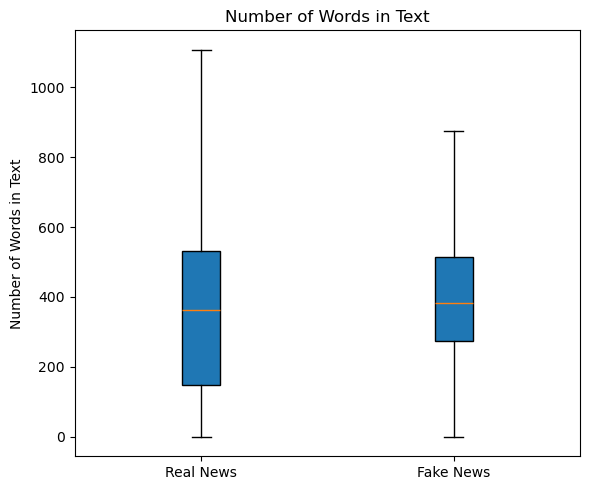

In [46]:
# Extract word counts for text based on target
real_text_word_count = df_words[df_words["target"] == 0]["n_words_in_text"]
fake_text_word_count = df_words[df_words["target"] == 1]["n_words_in_text"]

# Prepare data for plotting
data_to_plot_text = [real_text_word_count, fake_text_word_count]

# Create the boxplot
fig = plt.figure(figsize=[6, 5])
plt.boxplot(data_to_plot_text, vert=True, patch_artist=True, showfliers=False)

# Add title and labels
plt.title("Number of Words in Text")
plt.xticks([1, 2], ["Real News", "Fake News"])
plt.ylabel("Number of Words in Text")

plt.tight_layout()
plt.show()


**It seems that fake news have definitely longer titles, but relatively shorter bodies.**

Let's see if there are any notable differences in the ratio of title word length against the text of the article.

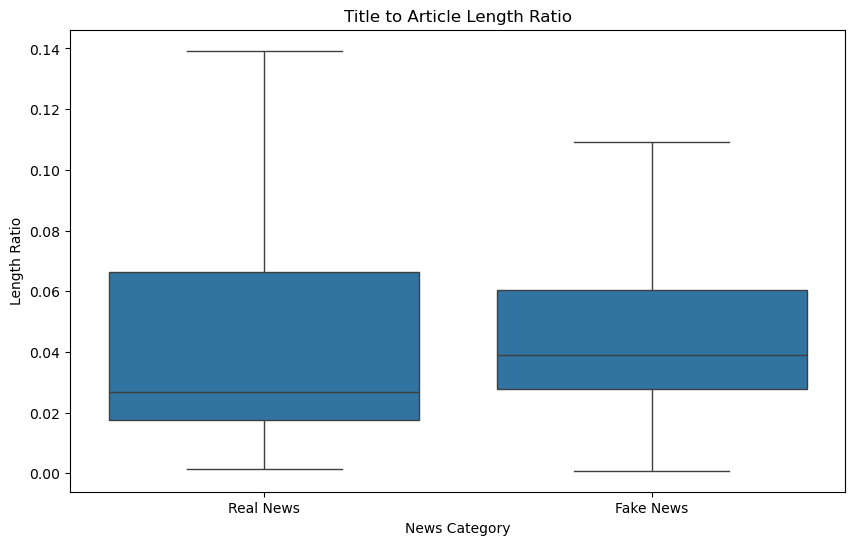

In [47]:
# Calculate title and article lengths
df['title_length'] = df['title'].apply(lambda x: len(word_tokenize(x)))
df['article_length'] = df['text'].apply(lambda x: len(word_tokenize(x)))

# Calculate the ratio for the entire dataset
df['length_ratio'] = df['title_length'] / df['article_length']

# Create variables for the fake and real news
fake_title_to_article_ratio = df[df['target'] == 1]['length_ratio']
real_title_to_article_ratio = df[df['target'] == 0]['length_ratio']

# Boxplot for the length ratio (Title to Article Length Ratio)
plt.figure(figsize=(10, 6))
sns.boxplot(x='target', y='length_ratio', data=df, showfliers=False)
plt.title('Title to Article Length Ratio')
plt.xlabel('News Category')
plt.ylabel('Length Ratio')
plt.xticks([0, 1], ['Real News', 'Fake News'])
plt.show()

In their research, Benjamin D. Horne and Sibel Adali note that in fake news titles, there are significantly more proper names and verbs, while significantly fewer stopwords and nouns are used. Let's check if this is the case with our dataset too. However, to eliminate the bias introduced by the longer fake news titles, we need to normalize the results and compute the length of each title (in terms of word count) and divide the counts by this length.

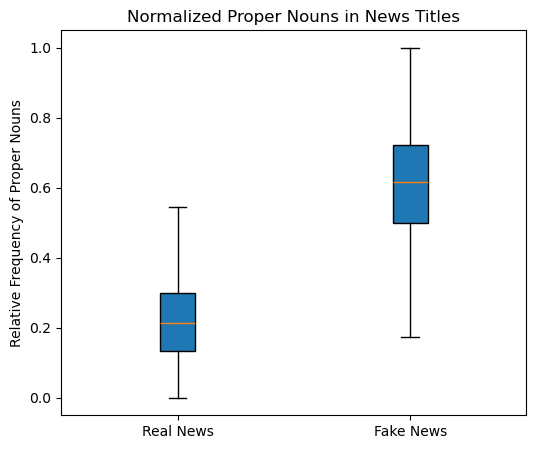

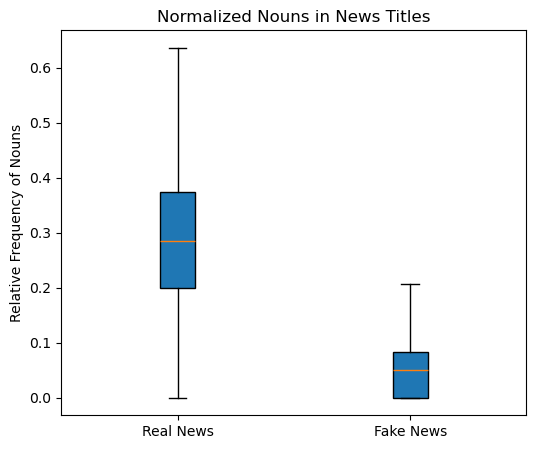

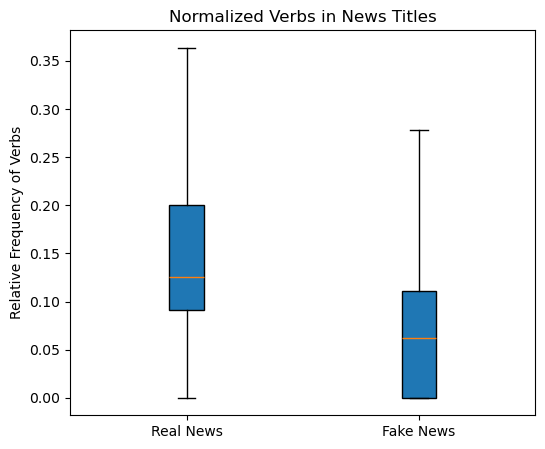

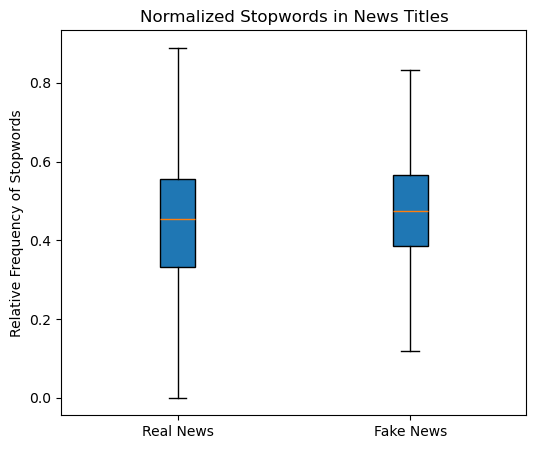

In [48]:
# Define the helper functions
def count_pos_tags(title, pos_tags_to_count, exclude_tags=[]):
    tokens = word_tokenize(title)
    pos_tags = nltk.pos_tag(tokens)
    return sum(1 for _, tag in pos_tags if tag in pos_tags_to_count and tag not in exclude_tags)

def count_stopwords(title, stopwords):
    tokens = word_tokenize(title)
    return sum(1 for word in tokens if word.lower() in stopwords)

def count_total_words(title):
    tokens = word_tokenize(title)
    return len(tokens)

# Define the POS tags for nouns, proper nouns, and verbs
proper_noun_tags = ['NNP', 'NNPS']
general_noun_tags = ['NN', 'NNS']
verb_tags = ['VB', 'VBD', 'VBG', 'VBN', 'VBP', 'VBZ']

# Variables to store data
fake_title_proper_nouns = []
real_title_proper_nouns = []

fake_title_nouns = []
real_title_nouns = []

fake_title_verbs = []
real_title_verbs = []

fake_title_stopwords = []
real_title_stopwords = []

# Process each row in the DataFrame
for _, row in df.iterrows():
    title = row['title']
    target = row['target']
    
    total_words = count_total_words(title)
    
    # Calculate relative counts
    proper_nouns_count = count_pos_tags(title, proper_noun_tags) / total_words
    nouns_count = count_pos_tags(title, general_noun_tags) / total_words
    verbs_count = count_pos_tags(title, verb_tags) / total_words
    stopwords_count = count_stopwords(title, news_stopwords) / total_words
    
    # Assign to the appropriate category
    if target == 0:  # Real news
        real_title_proper_nouns.append(proper_nouns_count)
        real_title_nouns.append(nouns_count)
        real_title_verbs.append(verbs_count)
        real_title_stopwords.append(stopwords_count)
    else:  # Fake news
        fake_title_proper_nouns.append(proper_nouns_count)
        fake_title_nouns.append(nouns_count)
        fake_title_verbs.append(verbs_count)
        fake_title_stopwords.append(stopwords_count)

# Visualize the results
pos_counts = {
    'Proper Nouns': {'Real': real_title_proper_nouns, 'Fake': fake_title_proper_nouns},
    'Nouns': {'Real': real_title_nouns, 'Fake': fake_title_nouns},
    'Verbs': {'Real': real_title_verbs, 'Fake': fake_title_verbs},
    'Stopwords': {'Real': real_title_stopwords, 'Fake': fake_title_stopwords},
}

for pos_category, counts in pos_counts.items():
    data_to_plot = [counts['Real'], counts['Fake']]
    
    fig = plt.figure(figsize=[6, 5])
    plt.boxplot(data_to_plot, vert=True, patch_artist=True, showfliers=False)
    plt.title(f"Normalized {pos_category} in News Titles")
    plt.xticks([1, 2], ["Real News", "Fake News"])
    plt.ylabel(f"Relative Frequency of {pos_category}")
    plt.show()


For our dataset, it is confirmed that the number of proper nouns in fake news titles is definitely larger, and the number of other nouns is larger in real news title. However, verbs are relatively more in real news titles, while the difference in the number of stopwords is not substantial.

Let's measure the lexical redundancy (Type-Token Ratio or TTR). we need to compare the number of unique words (types) to the total number of words (tokens) in the text. A lower TTR suggests more repetition of words (higher redundancy), and a higher TTR suggests a more varied vocabulary (lower redundancy).

$$
\text{TTR} = \frac{\text{Number of Unique Words (Types)}}{\text{Total Number of Words (Tokens)}}
$$


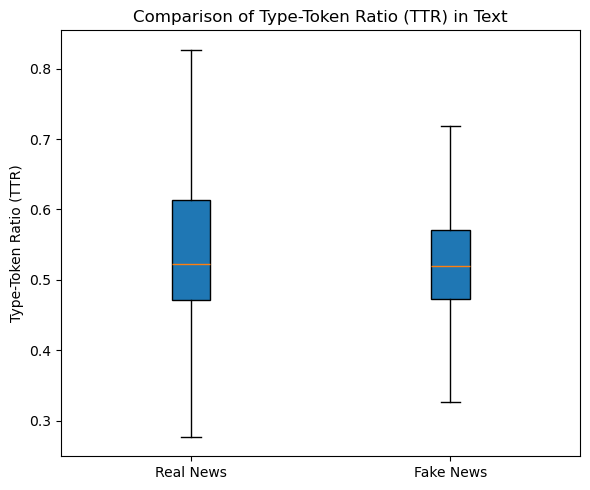

In [49]:
# Function to calculate TTR for each text in the dataset
def calculate_ttr(text):
    tokens = word_tokenize(text.lower())  # Tokenize and convert to lowercase
    total_tokens = len(tokens)  # Total number of tokens
    unique_tokens = len(set(tokens))  # Number of unique tokens (types)
    
   
    if total_tokens == 0:  # Prevent division by zero
        return 0
    return unique_tokens / total_tokens


df['TTR'] = df['text'].apply(calculate_ttr)

real_ttr = df[df['target'] == 0]['TTR']
fake_ttr = df[df['target'] == 1]['TTR']

data_to_plot = [real_ttr, fake_ttr]


fig = plt.figure(figsize = [6, 5])
plt.boxplot(data_to_plot, vert = True, patch_artist = True, showfliers = False)


plt.title('Comparison of Type-Token Ratio (TTR) in Text')
plt.xticks([1, 2], ["Real News", "Fake News"])
plt.ylabel('Type-Token Ratio (TTR)')

plt.tight_layout()
plt.show()

Fake news seem to have higher lexical redundancy.

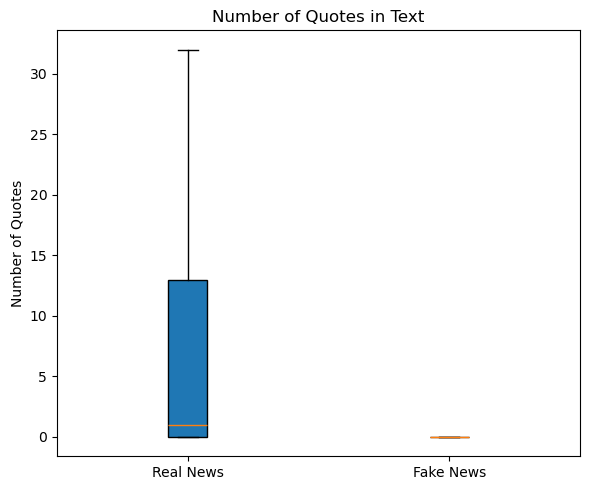

In [50]:
# Function to count the number of quotes in each article
def count_quotes(text):
    # Regex to count occurrences of quotes (double or single quotes)
    return len(re.findall(r'["“”‘’]', text))  # Matches regular and fancy quotes

# Apply the quote-counting function to the 'text' column
df['quote_count'] = df['text'].apply(count_quotes)

# Filter the quote counts for real (target == 0) and fake (target == 1) news
real_quote_count = df[df['target'] == 0]['quote_count']
fake_quote_count = df[df['target'] == 1]['quote_count']

# Prepare the data for the boxplot
data_to_plot = [real_quote_count, fake_quote_count]

# Create the boxplot
fig = plt.figure(figsize=[6, 5])
plt.boxplot(data_to_plot, vert=True, patch_artist=True, showfliers=False)

# Add title and labels
plt.title('Number of Quotes in Text')
plt.xticks([1, 2], ["Real News", "Fake News"])
plt.ylabel('Number of Quotes')

# Show the plot
plt.tight_layout()
plt.show()


We can see that fake news very rarely use quote, which can be a strong predictor to differentiate between the two.

### Training a Support Vector Machine (SVM) classifier with four features

Now let's train and evaluate the perfomance of four of the features explored above. Based on the boxplots, I have chosen the following features: **Number of Quotes in Text**, **Number of Words in Title**, **Normalized Proper Noun Count in Title** and **Normalized Verb Count**.

In [51]:
# Combine features into a unified dataset
features = {
    "Number of Quotes in Text": (fake_quote_count, real_quote_count),
    "Number of Words in Title": (fake_title_words, real_title_words),
    "Normalized Proper Noun Count in Title": (fake_title_proper_nouns, real_title_proper_nouns),
    "Normalized Verb Count in Title": (fake_title_verbs, real_title_verbs),
}

# Prepare the feature matrix and target vector
fake_features = []
real_features = []

for feature_name, (fake_values, real_values) in features.items():
    fake_features.append(fake_values)
    real_features.append(real_values)

# Convert to NumPy arrays and stack horizontally
fake_features = np.column_stack(fake_features)
real_features = np.column_stack(real_features)

# Combine fake and real features and create labels
X = np.vstack((fake_features, real_features))
y = np.array([1] * fake_features.shape[0] + [0] * real_features.shape[0])

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train an SVM classifier
svm_model = SVC(kernel = 'linear', random_state=42)
svm_model.fit(X_train, y_train)

# Make predictions
y_pred = svm_model.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.96      4254
           1       0.96      0.95      0.95      3567

    accuracy                           0.96      7821
   macro avg       0.96      0.96      0.96      7821
weighted avg       0.96      0.96      0.96      7821



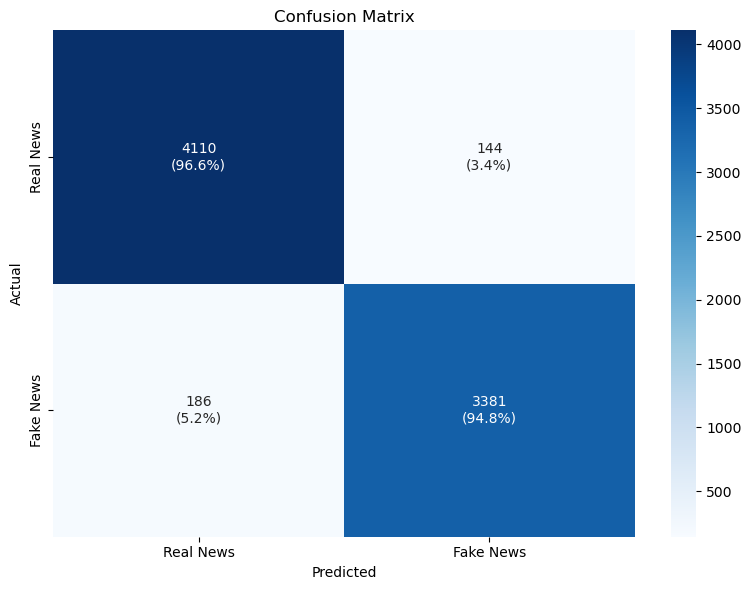

In [52]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

labels = np.asarray([
    [f"{count}\n({percent:.1f}%)" for count, percent in zip(row_counts, row_percentages)]
    for row_counts, row_percentages in zip(cm, cm_percentage)
])

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=labels,  
    fmt='',        
    cmap='Blues', 
    xticklabels=["Real News", "Fake News"], 
    yticklabels=["Real News", "Fake News"]
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

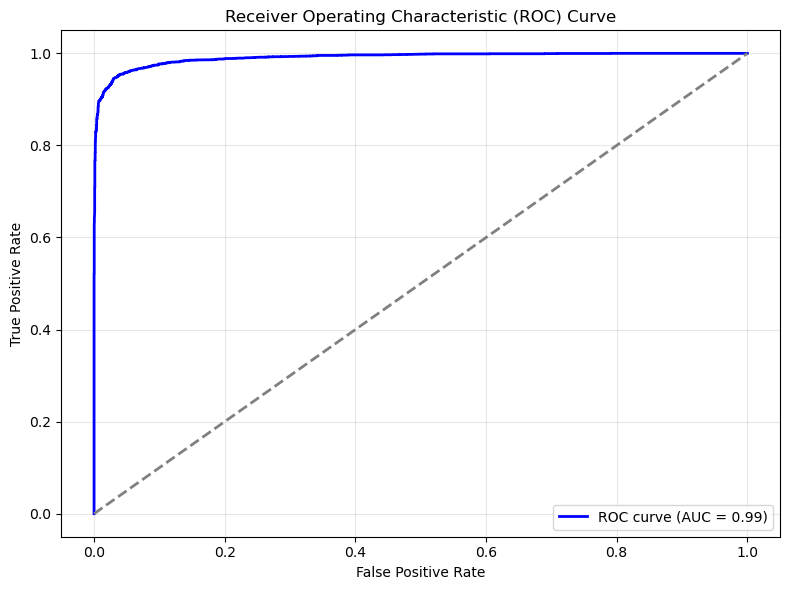

In [53]:
y_pred_prob = svm_model.decision_function(X_test) 


fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize = (8, 6))
plt.plot(fpr, tpr, color = 'blue', lw = 2, label = f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color = 'gray', linestyle = '--', lw=2)  
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The results using these four features are excellent, suggesting that they are very strong predictors for this classification.

### Model Creation Workflow

**1. Data Preprocessing:**

The text will be tokenized into words, then words will be lowercased and lemmatized. Non-alphabetical tokens and the stopwords specific for news will be removed.
The data will be split into three sets: train (60%), validation (20%) and test (20%).ipynb_checkpoints/

**2. Model Pipeline Creation:**

The model will include the following steps:

TfidfVectorizer: Converts text into numerical features using TF-IDF, based on previous research it ouperforms TF.
MaxAbsScaler: Scales features to handle sparse data efficiently.
TruncatedSVD: Reduces dimensionality for faster computation and better generalization.
classifier: The algorithms to be tested.

**3. Define Models and Objective Function**

Defines the hyperparameter space for models and pecifies what the model or algorithm is optimizing.

**4. Hyperparameter Optimization**

Uses HyperOpt to find the best model and parameters.

**5. Log and Save Model**
Saving will be done using pickle, while using mlflow.

First, let's join all text data into one column:

In [55]:
df['final'] =  df['title'] + " " + df['subject']

In [58]:
# Set a fixed random state for reproducibility
RANDOM_STATE = 42

# Initialize the lemmatizer
lemmatizer = WordNetLemmatizer()

# 1. Data Preprocessing
def clean_text(text, news_stopwords):
    tokens = word_tokenize(text)
    cleaned_tokens = [
        lemmatizer.lemmatize(word.lower()) for word in tokens
        if word.isalpha() and word.lower() not in news_stopwords
    ]
    return " ".join(cleaned_tokens)

def preprocess_data(df, news_stopwords):
    df['cleaned_text'] = df['final'].apply(lambda x: clean_text(x, news_stopwords))
    X = df['cleaned_text']
    y = df['target']
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=RANDOM_STATE, stratify=y)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE, stratify=y_temp)
    return X_train, X_val, X_test, y_train, y_val, y_test

# 2. Model Setup
def create_pipeline(model):
    tfidf_vectorizer = TfidfVectorizer(max_features=10000)
    maxabs_scaler = MaxAbsScaler()
    svd = TruncatedSVD(n_components=200, random_state=RANDOM_STATE)
    pipeline = Pipeline([
        ('tfidf', tfidf_vectorizer),
        ('scaler', maxabs_scaler),
        ('svd', svd),
        ('classifier', model)
    ])
    return pipeline

# 3. Hyperparameter Space
# We choose the model_name separately from its parameters.
space = {
    'model_name': hp.choice('model_name', ['sgd', 'svm', 'dt', 'lr', 'rf']),
    # SGD parameters
    'sgd_max_iter': hp.choice('sgd_max_iter', [1000, 1500, 2000]),
    'sgd_alpha': hp.uniform('sgd_alpha', 0.0001, 0.1),
    # SVM parameters
    'svm_C': hp.uniform('svm_C', 0.1, 10),
    # Decision Tree parameters
    'dt_max_depth': hp.choice('dt_max_depth', [5, 10, 20]),
    # Logistic Regression parameters
    'lr_max_iter': hp.choice('lr_max_iter', [100, 200, 300]),
    'lr_C': hp.uniform('lr_C', 0.1, 10),
    # Random Forest parameters
    'rf_n_estimators': hp.choice('rf_n_estimators', [50, 100, 150]),
    'rf_max_depth': hp.choice('rf_max_depth', [10, 20, 30]),
    'rf_min_samples_split': hp.choice('rf_min_samples_split', [2, 5, 10])
}

def evaluate_model(pipeline, X_val, y_val):
    y_pred = pipeline.predict(X_val)
    y_prob = pipeline.predict_proba(X_val)[:, 1] if hasattr(pipeline['classifier'], "predict_proba") else None
    precision, recall, f1, _ = precision_recall_fscore_support(y_val, y_pred, average='binary', zero_division=1)
    auc = roc_auc_score(y_val, y_prob) if y_prob is not None else None
    accuracy = accuracy_score(y_val, y_pred)
    return precision, recall, f1, accuracy, auc

def objective(params, X_train, y_train, X_val, y_val, performance_table):
    model_name = params['model_name']

    if model_name == 'sgd':
        model = SGDClassifier(
            max_iter=params['sgd_max_iter'],
            alpha=params['sgd_alpha'],
            random_state=RANDOM_STATE
        )
    elif model_name == 'svm':
        model = SVC(
            C=params['svm_C'],
            random_state=RANDOM_STATE,
            probability=True
        )
    elif model_name == 'dt':
        model = DecisionTreeClassifier(
            max_depth=params['dt_max_depth'],
            random_state=RANDOM_STATE
        )
    elif model_name == 'lr':
        model = LogisticRegression(
            max_iter=params['lr_max_iter'],
            C=params['lr_C'],
            random_state=RANDOM_STATE
        )
    elif model_name == 'rf':
        model = RandomForestClassifier(
            n_estimators=params['rf_n_estimators'],
            max_depth=params['rf_max_depth'],
            min_samples_split=params['rf_min_samples_split'],
            random_state=RANDOM_STATE
        )
    else:
        raise ValueError(f"Unrecognized model type: {model_name}")

    pipeline = create_pipeline(model)
    pipeline.fit(X_train, y_train)
    metrics = evaluate_model(pipeline, X_val, y_val)
    performance_table.append((model_name, params, *metrics))
    # We want to maximize F1 score, so we minimize negative F1
    return -metrics[2]

# 4. Hyperparameter Optimization
def hyperopt_optimization(X_train, y_train, X_val, y_val):
    performance_table = []
    trials = Trials()
    best = fmin(
        fn=lambda p: objective(p, X_train, y_train, X_val, y_val, performance_table),
        space=space,
        algo=tpe.suggest,
        max_evals=20,
        trials=trials
    )
    performance_df = pd.DataFrame(performance_table, columns=['Model', 'Parameters', 'Precision', 'Recall', 'F1', 'Accuracy', 'AUC'])
    return best, performance_df

# 5. Log Results and Save Model
def log_and_save_model(final_pipeline, metrics, best_params):
    if mlflow.active_run():
        mlflow.end_run()
    with mlflow.start_run():
        mlflow.log_param("Best Parameters", best_params)
        mlflow.log_metrics({
            "Precision": metrics[0],
            "Recall": metrics[1],
            "F1 Score": metrics[2],
            "Accuracy": metrics[3],
            "AUC": metrics[4]
        })
        pickle_file = 'best_model.pkl'
        with open(pickle_file, 'wb') as f:
            pickle.dump(final_pipeline, f)
        mlflow.log_artifact(pickle_file)

# 6. Main Workflow
if __name__ == "__main__":
    # Assuming `df` and `news_stopwords` are defined
    X_train, X_val, X_test, y_train, y_val, y_test = preprocess_data(df, news_stopwords)
    best_params, performance_df = hyperopt_optimization(X_train, y_train, X_val, y_val)

    # Extract the chosen model name from best_params
    model_name = ['sgd', 'svm', 'dt', 'lr', 'rf'][best_params['model_name']]

    if model_name == 'sgd':
        best_model = SGDClassifier(
            max_iter=best_params['sgd_max_iter'],
            alpha=best_params['sgd_alpha'],
            random_state=RANDOM_STATE
        )
    elif model_name == 'svm':
        best_model = SVC(
            C=best_params['svm_C'],
            random_state=RANDOM_STATE,
            probability=True
        )
    elif model_name == 'dt':
        best_model = DecisionTreeClassifier(
            max_depth=best_params['dt_max_depth'],
            random_state=RANDOM_STATE
        )
    elif model_name == 'lr':
        best_model = LogisticRegression(
            max_iter=best_params['lr_max_iter'],
            C=best_params['lr_C'],
            random_state=RANDOM_STATE
        )
    elif model_name == 'rf':
        best_model = RandomForestClassifier(
            n_estimators=best_params['rf_n_estimators'],
            max_depth=best_params['rf_max_depth'],
            min_samples_split=best_params['rf_min_samples_split'],
            random_state=RANDOM_STATE
        )
    else:
        raise ValueError(f"Unrecognized model type: {model_name}")

    final_pipeline = create_pipeline(best_model)
    final_pipeline.fit(X_train, y_train)
    test_metrics = evaluate_model(final_pipeline, X_test, y_test)
    print("Test Metrics:", test_metrics)
    log_and_save_model(final_pipeline, test_metrics, best_params)

    print("Performance Table:")
    print(performance_df)


100%|████████████████████████████████████████████| 20/20 [1:08:52<00:00, 206.61s/trial, best loss: -0.8651813767495001]
Test Metrics: (0.892678623934137, 0.8478078748952806, 0.8696648524778001, 0.883646592507352, 0.9507683041524188)
Performance Table:
   Model                                         Parameters  Precision  \
0     rf  {'dt_max_depth': 5, 'lr_C': 2.63654636872949, ...   0.866529   
1    sgd  {'dt_max_depth': 5, 'lr_C': 8.411054783229709,...   0.974398   
2     rf  {'dt_max_depth': 20, 'lr_C': 9.071156071201143...   0.862607   
3     dt  {'dt_max_depth': 5, 'lr_C': 3.3895035635495865...   0.781191   
4    sgd  {'dt_max_depth': 5, 'lr_C': 6.098689428807557,...   1.000000   
5    svm  {'dt_max_depth': 10, 'lr_C': 5.142587562836837...   0.885088   
6     lr  {'dt_max_depth': 5, 'lr_C': 2.043236793333104,...   0.874339   
7    svm  {'dt_max_depth': 20, 'lr_C': 1.856439272897829...   0.885472   
8     lr  {'dt_max_depth': 5, 'lr_C': 5.880876495535413,...   0.874199   
9     rf

In [61]:
performance_df

,Model,Parameters,Precision,Recall,F1,Accuracy,AUC
0,rf,"{'dt_max_depth': 5, 'lr_C': 2.63654636872949, ...",0.866529,0.821050,0.843177,0.860120,0.931097
1,sgd,"{'dt_max_depth': 5, 'lr_C': 8.411054783229709,...",0.974398,0.180625,0.304757,0.622555,NaN
2,rf,"{'dt_max_depth': 20, 'lr_C': 9.071156071201143...",0.862607,0.818537,0.839994,0.857179,0.931152
3,dt,"{'dt_max_depth': 5, 'lr_C': 3.3895035635495865...",0.781191,0.802345,0.791626,0.806546,0.878320
4,sgd,"{'dt_max_depth': 5, 'lr_C': 6.098689428807557,...",1.000000,0.000000,0.000000,0.542002,NaN
5,svm,"{'dt_max_depth': 10, 'lr_C': 5.142587562836837...",0.885088,0.845059,0.864610,0.878788,0.946534
6,lr,"{'dt_max_depth': 5, 'lr_C': 2.043236793333104,...",0.874339,0.831379,0.852318,0.868048,0.937943
7,svm,"{'dt_max_depth': 20, 'lr_C': 1.856439272897829...",0.885472,0.843942,0.864208,0.878532,0.946247
8,lr,"{'dt_max_depth': 5, 'lr_C': 5.880876495535413,...",0.874199,0.838079,0.855758,0.870605,0.938936
9,rf,"{'dt_max_depth': 10, 'lr_C': 8.929634725758659...",0.852984,0.817979,0.835115,0.852065,0.925373


In [74]:
performance_df.sort_values(by=['Accuracy', 'Model'], ascending=[False, True])

,Model,Parameters,Precision,Recall,F1,Accuracy,AUC
15,svm,"{'dt_max_depth': 20, 'lr_C': 4.062369050996395...",0.885673,0.845617,0.865181,0.879299,0.946568
14,svm,"{'dt_max_depth': 20, 'lr_C': 9.295908774366051...",0.885639,0.845338,0.865019,0.879171,0.946567
5,svm,"{'dt_max_depth': 10, 'lr_C': 5.142587562836837...",0.885088,0.845059,0.864610,0.878788,0.946534
13,svm,"{'dt_max_depth': 10, 'lr_C': 8.390432329518939...",0.884829,0.845059,0.864487,0.878660,0.946526
7,svm,"{'dt_max_depth': 20, 'lr_C': 1.856439272897829...",0.885472,0.843942,0.864208,0.878532,0.946247
18,lr,"{'dt_max_depth': 20, 'lr_C': 7.960063871841453...",0.873440,0.840034,0.856411,0.870988,0.939122
8,lr,"{'dt_max_depth': 5, 'lr_C': 5.880876495535413,...",0.874199,0.838079,0.855758,0.870605,0.938936
6,lr,"{'dt_max_depth': 5, 'lr_C': 2.043236793333104,...",0.874339,0.831379,0.852318,0.868048,0.937943
0,rf,"{'dt_max_depth': 5, 'lr_C': 2.63654636872949, ...",0.866529,0.821050,0.843177,0.860120,0.931097
16,rf,"{'dt_max_depth': 5, 'lr_C': 6.326911483402495,...",0.861867,0.822166,0.841549,0.858202,0.931743


SVM is the best perfomring algorithm, followed by LR. There seems to some problem with SGD, unfortunately, as the deadline is on me, I am not able to further explore.

In [59]:
with open('final_model.pkl', 'rb') as file:
    model = pickle.load(file)

In [60]:
model

Pipeline(steps=[('tfidf', TfidfVectorizer(max_features=10000)),
                ('scaler', MaxAbsScaler()),
                ('svd', TruncatedSVD(n_components=200, random_state=42)),
                ('classifier',
                 SVC(C=2.275412005441069, probability=True, random_state=42))])

### Results

In [62]:
classifier = final_pipeline.named_steps['classifier']
print(classifier)

SVC(C=3.769423252716349, probability=True, random_state=42)


The best model is an **SVM classifier** with a complexity (C=3.77).

**References**:
1. Detection of Online Fake News Using N-Gram Analysis and Machine Learning Techniques, by Hadeer Ahmed, Issa Traore, and Sherif Saad [link](https://sci-hub.se/10.1007/978-3-319-69155-8_9)
   
2. "Fake News," Lies and Propaganda: How to Sort Fact from Fiction University of Michigan Library [link](https://guides.lib.umich.edu/fakenews)

3. LSTMCNN: A hybrid machine learning model to unmask fake news, by Deepali Goyal et al. Dev [link](https://www.sciencedirect.com/science/article/pii/S2405844024012751?ref=pdf_download&fr=RR-2&rr=8e37198648ff8ef3#bib8)
   
4. FakenewsPoster2016 by Benjamin D. Horne and Sibel Adalı [link](https://benjamindhorne.github.io/slides/FakenewsPoster2016_34inwide_banded.pdf)
   
5. This Just In: Fake News Packs a Lot in Title, Uses Simpler, Repetitive Content in Text Body, More Similar to Satire than Real News by Benjamin D. Horne and Sibel Adalı [link](https://www.semanticscholar.org/reader/1b321bb759233167fc5a53009dd70782eee07cb9)
   
6. A Comparative Study of Hybrid Machine Learning Approaches for Fake News Detection that Combine Multi-Stage Ensemble Learning and NLP-based Framework by Gaurav J. Singh and Dr. Selvakumar K [link](https://www.techrxiv.org/users/688061/articles/680534/master/file/data/TechRxiv/TechRxiv.pdf)

7. 2017 Year in Review: Here are the top 10 biggest news stories by NBC News [link](https://www.nbcnews.com/news/us-news/2017-year-review-here-are-top-10-biggest-news-stories-n828881)
 
8. 2016’s top 10 news stories ranked by the Associated Press by MarketWatch [link](https://www.marketwatch.com/story/2016s-top-10-news-stories-ranked-by-the-associated-press-2016-12-21)

9. What Do We Call “Mushroom” Websites? [link](https://sensika.com/blog/disinformation/what-do-we-call-mushroom-websites/)
